## Deep dream with CLIP

In [1]:
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to c:\users\janba\appdata\local\temp\pip-req-build-_5iv9m53
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git 'C:\Users\janba\AppData\Local\Temp\pip-req-build-_5iv9m53'

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import torch
import torch.nn.functional as F

import clip
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
# model, preprocess = clip.load('RN101', device=device)
model, preprocess = clip.load('ViT-L/14', device=device)

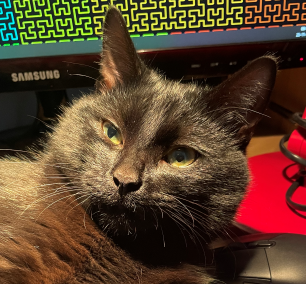

In [4]:
target_img = Image.open("../datasets/image_sample/kat.png")
target_img

In [5]:
image = preprocess(target_img).unsqueeze(0).to(device)

image_features = model.encode_image(image)

image_features.shape

c:\Users\janba\anaconda3\envs\workspace_jan\Lib\site-packages\torch\nn\functional.py:5476: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:263.)
  attn_output = scaled_dot_product_attention(q, k, v, attn_mask, dropout_p, is_causal)


torch.Size([1, 768])

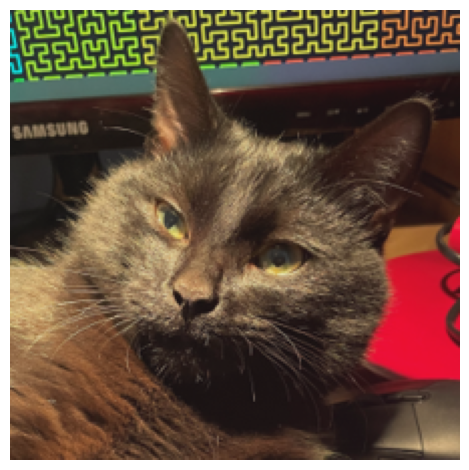

In [6]:
# for reference: torchvision uses this normalization scheme
# normalize = Normalize(mean=[0.485, 0.456, 0.406],
#                         std=[0.229, 0.224, 0.225])
std = np.array([0.229, 0.224, 0.225]).reshape(1, 1, -1)
mean = np.array([0.485, 0.456, 0.406]).reshape(1, 1, -1)

np_noise = (image).detach().cpu().squeeze().permute(1, 2, 0).numpy()
normalized_img = np.clip(((np_noise * std) + mean), 0, 1)

plt.imshow(normalized_img)
plt.axis('off')

plt.tight_layout()
plt.show()

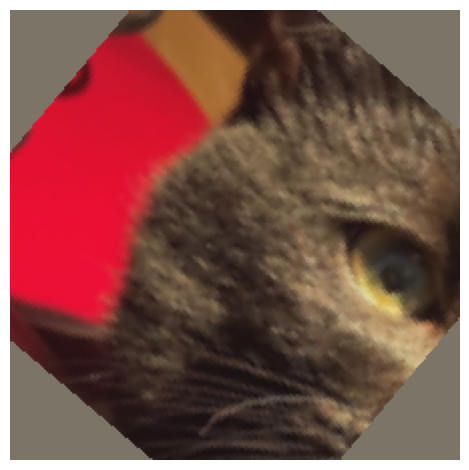

In [7]:
from torchvision.transforms import v2

# for reference: torchvision uses this normalization scheme
# normalize = Normalize(mean=[0.485, 0.456, 0.406],
#                         std=[0.229, 0.224, 0.225])
std = np.array([0.229, 0.224, 0.225]).reshape(1, 1, -1)
mean = np.array([0.485, 0.456, 0.406]).reshape(1, 1, -1)

# Can compose multiple transforms
compose = v2.Compose([
    v2.RandomResizedCrop(224, scale=(0.2, 0.2)),
    v2.RandomHorizontalFlip(),
    v2.RandomRotation(45),
])

np_noise = (compose(image)).detach().cpu().squeeze().permute(1, 2, 0).numpy()
normalized_img = np.clip(((np_noise * std) + mean), 0, 1)

plt.imshow(normalized_img)
plt.axis('off')

plt.tight_layout()
plt.show()


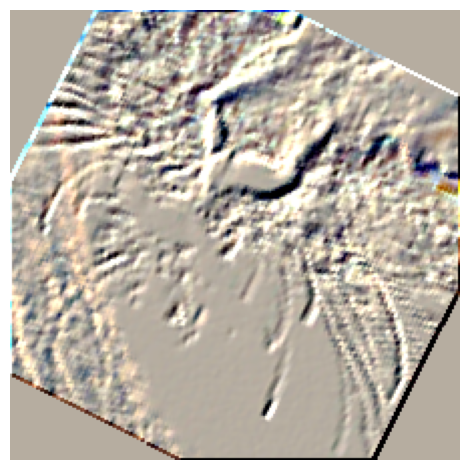

In [10]:
sobel_x = torch.tensor([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=torch.float32).repeat(3, 1, 1, 1).to(device)
        
sobel_y = torch.tensor([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=torch.float32).repeat(3, 1, 1, 1).to(device)

c_img = compose(image)

sobel_img = 1-((F.conv2d(c_img, sobel_x, padding=1, groups=3) + F.conv2d(c_img, sobel_y, padding=1, groups=3)))

np_noise = sobel_img.detach().cpu().squeeze().permute(1, 2, 0).numpy()
normalized_img = np.clip(((np_noise * std) + mean), 0, 1)

plt.imshow(normalized_img)
plt.axis('off')

plt.tight_layout()
plt.show()

In [11]:
import torchvision.transforms.functional as TF

sobel_x = torch.tensor([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=torch.float32).repeat(3, 1, 1, 1).to(device)
        
sobel_y = torch.tensor([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=torch.float32).repeat(3, 1, 1, 1).to(device)

def total_variation_loss(img, weight, p=2):
     tv_h = torch.abs(F.pad(img[:,:,1:,:]-img[:,:,:-1,:], (0, 0, 0, 1)))**p
     tv_w = torch.abs(F.pad(img[:,:,:,1:]-img[:,:,:,:-1], (0, 1, 0, 0)))**p
     diag_1 = torch.abs(F.pad(img[:, :, 1:, 1:] - img[:, :, :-1, :-1], (0, 1, 0, 1)))**p
     diag_2 = torch.abs(F.pad(img[:, :, 1:, :-1] - img[:, :, :-1, 1:], (0, 1, 0, 1)))**p

    #  mask = 1 - F.sigmoid(F.conv2d(img, sobel_x, padding=1, groups=3) + F.conv2d(img, sobel_y, padding=1, groups=3))

     return weight * ((tv_h + tv_w + diag_1 + diag_2)).mean()

def blur_loss(img, sigma=1.0):
    # Penalize high frequencies by encouraging smoothness
    blurred_image = TF.gaussian_blur(img, kernel_size=[5, 5], sigma=[1.0, 1.0])
    return sigma*torch.nn.functional.mse_loss(img, blurred_image)

In [12]:
from torchvision.transforms import v2

compose = v2.Compose([
    v2.RandomResizedCrop(224, scale=(0.2, 0.2)),
    v2.RandomHorizontalFlip(),
    v2.RandomRotation(360),
])

0 0.8161022067070007
1 0.8188562989234924
2 0.8259251713752747
3 0.8176255822181702
4 0.8137903213500977
5 0.8120214343070984
6 0.8135008811950684
7 0.8125960826873779
8 0.8149782419204712
9 0.8112663626670837
10 0.8146965503692627
11 0.8088548183441162
12 0.8096641302108765
13 0.8079956769943237
14 0.8136281371116638
15 0.8160696029663086
16 0.8146120309829712
17 0.8127885460853577
18 0.8103316426277161
19 0.8174712061882019
20 0.8128288388252258
21 0.8105314373970032
22 0.7949670553207397
23 0.804078996181488
24 0.8050738573074341
25 0.8029512763023376
26 0.7962062358856201
27 0.8139299750328064
28 0.8082810044288635
29 0.8071499466896057
30 0.7983687520027161
31 0.8106783032417297
32 0.8057157397270203
33 0.8052329421043396
34 0.8128328919410706
35 0.804728627204895
36 0.8051777482032776
37 0.80463707447052
38 0.8119232654571533
39 0.8172686100006104
40 0.8157140016555786
41 0.8034341931343079
42 0.8150123357772827
43 0.80207359790802
44 0.8106781840324402
45 0.8059085607528687
46 0

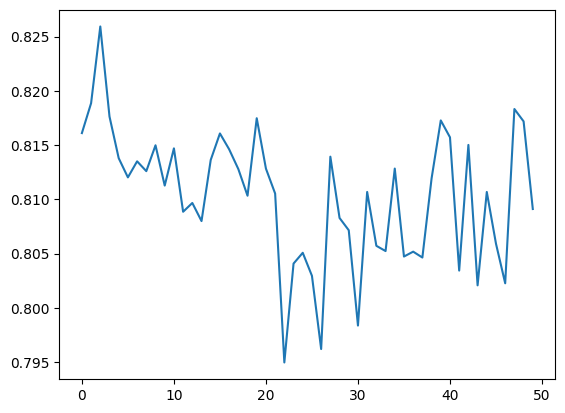

In [18]:
img_param = torch.nn.Parameter(image.to(device))

text_emb = model.encode_text(clip.tokenize('dog').to(device)).detach().squeeze(0)

epochs = 50
batch_size = 10

optim = torch.optim.Adam([img_param], lr=0.1)
scheduler = torch.optim.lr_scheduler.LinearLR(optim, 0.95, 1.0, epochs)

lam_tv = 0.1
# lam_decay_l1 = 0.0 #0.000005
# lam_decay_l2 = 0.0 #0.000005
# lam_blur = 0.0 #0.01
# lam_consistency = 0.01

losses = []

for i in range(epochs):

    batch = torch.vstack([compose(img_param) + 0.01*torch.randn(*img_param.shape).to(device) for _ in range(batch_size)])

    img_emb = model.encode_image(batch)

    cos_loss = (1 - (img_emb @ text_emb)/(img_emb.norm(dim=-1) * text_emb.norm())).mean()
    # blur = blur_loss(batch, lam_blur)
    tv_loss = total_variation_loss(batch, lam_tv)
    # reg_l1 = lam_decay_l1*img_param.norm(p=1)
    # reg_l2 = lam_decay_l2*img_param.norm(p=2)
    # consistency_loss = lam_consistency*F.mse_loss(img_param, image.to(device))

    total_loss = cos_loss + tv_loss # + consistency_loss + # blur + reg_l2 #+ reg_l1

    optim.zero_grad()

    total_loss.backward()
    # torch.nn.utils.clip_grad_value_(img_param, 1.0)

    # img_param.grad = F.tanh(TF.gaussian_blur(img_param.grad, kernel_size=[3, 3], sigma=[0.5, 0.5]))

    optim.step()
    scheduler.step()

    losses.append(total_loss.item())
    print(i, losses[-1])

plt.plot(losses)

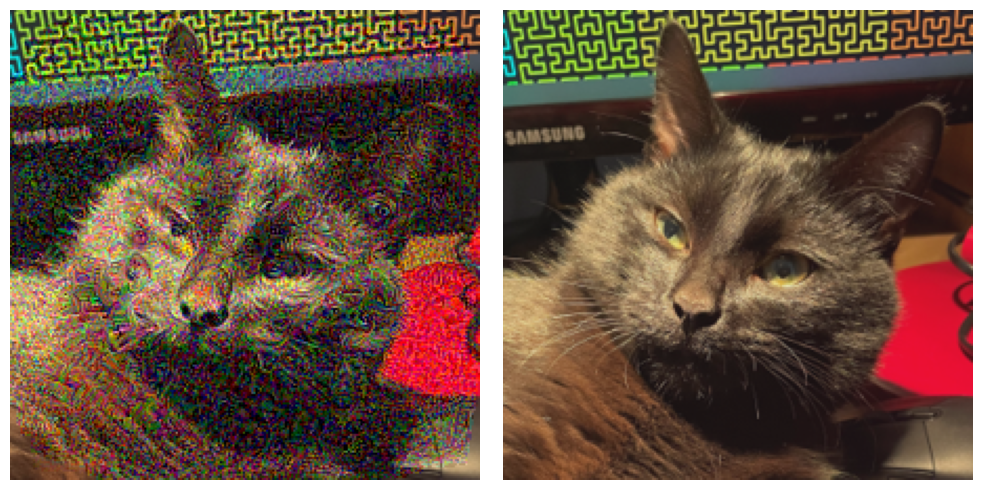

In [19]:
# for reference: torchvision uses this normalization scheme
# normalize = Normalize(mean=[0.485, 0.456, 0.406],
#                         std=[0.229, 0.224, 0.225])
std = np.array([0.229, 0.224, 0.225]).reshape(1, 1, -1)
mean = np.array([0.485, 0.456, 0.406]).reshape(1, 1, -1)

np_noise = (img_param).detach().cpu().squeeze().permute(1, 2, 0).numpy()
normalized_img = np.clip(((np_noise * std) + mean), 0, 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(normalized_img)
ax1.axis('off')

image = preprocess(target_img).unsqueeze(0).to(device)

np_noise = (image).detach().cpu().squeeze().permute(1, 2, 0).numpy()
normalized_img = np.clip(((np_noise * std) + mean), 0, 1)

ax2.imshow(normalized_img)
ax2.axis('off')

plt.tight_layout()
plt.show()